## Context
I leveraged historical data from the CES survey at verification flow drop off and readily available transaction data as a proof of concept and conversation starter, to understand if there was the possibility of detecting downstream economic impact from measuring user perception (in this case perceived effort - which could mean friction, but might not. More on that later). 

This analysis isn't causal, and there are a lot of other variables that would be useful as inputs to make a true conclusion. The purpose of this study was to start the conversation (and teach me about Wise's data landscape). I wanted to answer the question - is this a thread worth pulling. The data show the answer is **yes**, and I hope this work can kick off converseations and a more in depth workstream to close some of the gaps implicit in this analysis.

## Summary of Findings

**Key finding:** CES score from the personal verification flow is a statistically significant predictor of follow-on transfer frequency across all platforms. After controlling for country and platform, each 1-point CES increase is **associated*** with **7.9% more follow-on transfers** (negative binomial regression, p<0.0001). This is the strongest and most consistent behavioral signal in the data.

*Important note - **correlation != causation!** While this is a great signal, there are many caveats and unknowns and we shouldn't start going on an 8% transaction increase from driving CES improvements (...yet). 

### What CES predicts well:
- **Follow-on transfer count** — significant across all platforms (Kruskal-Wallis: Android p=0.002, iOS p=0.008, Web p<0.0001). Top-3-box users make more repeat transfers than bottom-box users.
- **Conversion to first transfer (mobile only)** — Android (p=0.0005) and iOS (p=0.0002) show a ~5-8pp conversion lift for higher CES users. Web shows no significant relationship.

### What CES does not predict:
- **Transfer value** — no meaningful relationship on mobile. Web shows significance but this may be driven by a few high-value outliers.
- **First transfer amount** — no pattern, which is actually useful: it confirms CES measures verification friction, not user wealth/intent.
- **Time to first transfer** — counterintuitively, lower-CES users transfer *faster*. Multiple explanations are plausible (urgency bias, review delays, selection). However, an interaction test confirms this does NOT moderate the repeat-transfer finding — the CES effect is consistent across fast and slow converters.

In [39]:
#load the data, do initial cleaning and feature engineering, load libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import sys
sys.path.insert(0, '/Users/bryan.carroll/Library/CloudStorage/GoogleDrive-bryan.carroll@wise.com/My Drive/BryWise/AI')
import wise_colours  # type: ignore[import-unresolved]

# Load the data
full_data = pd.read_csv('ces_transactions3.csv')

# Deduplicate survey responses: keep only the first survey per user
first_survey = full_data.groupby('USER_ID')['SURVEY_DATE'].transform('min')
full_data = full_data[full_data['SURVEY_DATE'] == first_survey]

# Time to first transfer in hours
full_data['time_to_first_transfer'] = (pd.to_datetime(full_data['FIRST_TRANSFER_DATE']) - pd.to_datetime(full_data['SURVEY_DATE'])) / pd.Timedelta(days=1)

df = full_data.copy()

# Remove rows where time to first transfer is negative
df = df[df['time_to_first_transfer'] >= 0]

df['FIRST_TRANSFER_MONTH'] = pd.to_datetime(df['FIRST_TRANSFER_DATE']).dt.to_period('M')
df['SEND_MONTH'] = pd.to_datetime(df['SEND_MONTH']).dt.to_period('M')
df['SURVEY_MONTH'] = pd.to_datetime(df['SURVEY_DATE']).dt.to_period('M')




### Important caveats:
1. **Causality is not established.** Users with inherently stronger intent to use Wise may both rate the experience higher and transact more. This analysis shows association, not that improving CES *causes* more transfers.
2. **Survivorship bias.** Users who rage-quit during verification never took the survey — the worst-experience users are missing from the data entirely.
3. **Perception-based measurement.** User motivations and mental models add noise to the CES signal. This data wasn't designed for this kind of longitudinal analysis; properly designed measurement systems would mitigate these issues.
4. **Additional behaviors.** This analysis does not capture pre-survey behavior such as verification attempts, document rejections, etc. Some of this is unavailable due to my limited context, but much may be impossible to connect due to limitations in measurement system design.   

### Implication:
There is evidence of a downstream economic benefit to Wise from improving verification experiences (more repeat transactions), but properly designed experimentation and measurement systems with more data would be needed to quantify the true effect and isolate its drivers.

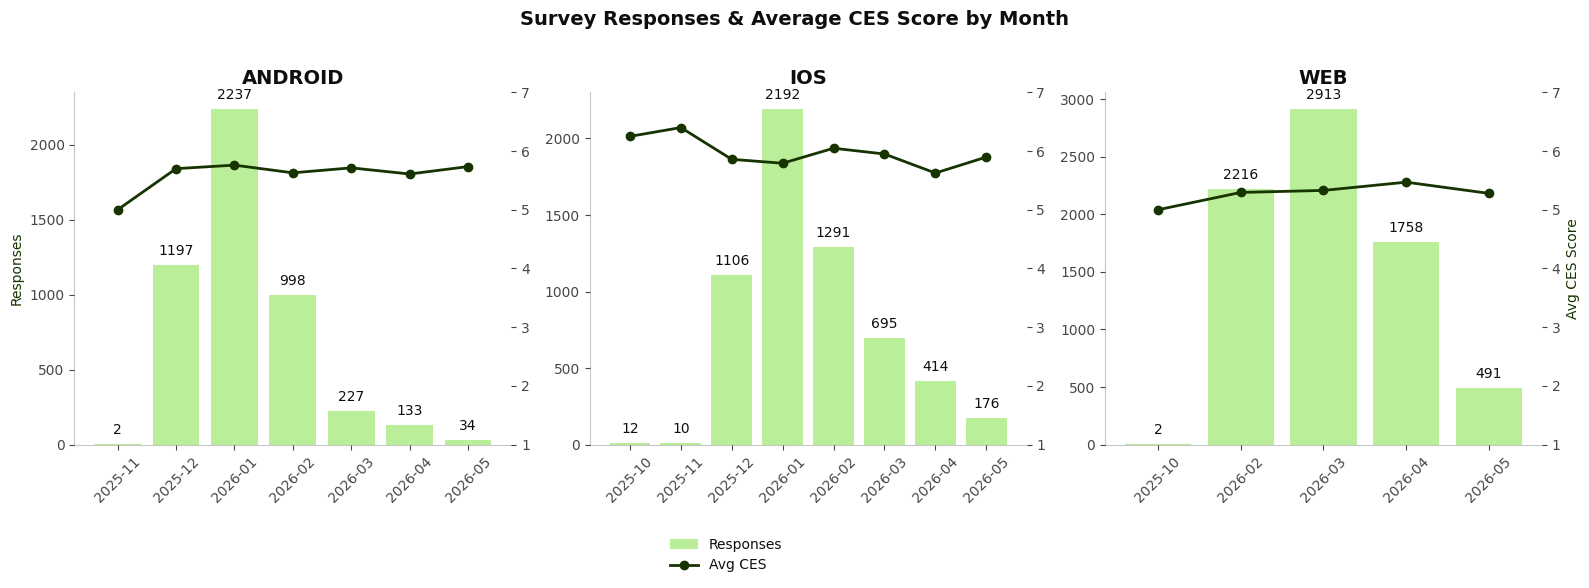

In [40]:
#show responses and average CES by month for each platform
platforms = ['ANDROID', 'IOS', 'WEB']
monthly = df[df['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'SURVEY_MONTH']).agg(
    responses=('CES_SCORE', 'count'),
    avg_ces=('CES_SCORE', 'mean')
).reset_index()
monthly['SURVEY_MONTH'] = monthly['SURVEY_MONTH'].astype(str)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for i, (ax, platform) in enumerate(zip(axes, platforms)):
    data = monthly[monthly['PLATFORM'] == platform]
    
    ax.bar(data['SURVEY_MONTH'], data['responses'], color=wise_colours.BRIGHT_GREEN, alpha=0.7, label='Responses')
    ax.set_xlabel('')
    ax.set_ylabel('Responses' if i == 0 else '', color=wise_colours.FOREST_GREEN)
    ax.set_title(platform)
    ax.tick_params(axis='x', rotation=45)
    
    ax2 = ax.twinx()
    ax2.plot(data['SURVEY_MONTH'], data['avg_ces'], color=wise_colours.FOREST_GREEN, marker='o', linewidth=2, label='Avg CES')
    ax2.set_ylim(1, 7)
    ax2.set_ylabel('Avg CES Score' if i == len(platforms) - 1 else '', color=wise_colours.FOREST_GREEN)

    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():1}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Survey Responses & Average CES Score by Month', fontsize=14, y=1.02)
handles1, labels1 = axes[0].get_legend_handles_labels()
handles2, labels2 = axes[0].get_shared_x_axes().get_siblings(axes[0])[0].get_legend_handles_labels()  
fig.legend(handles1 + handles2, labels1 + labels2, bbox_to_anchor=(0.5, -0.01))
fig.tight_layout()
plt.show()

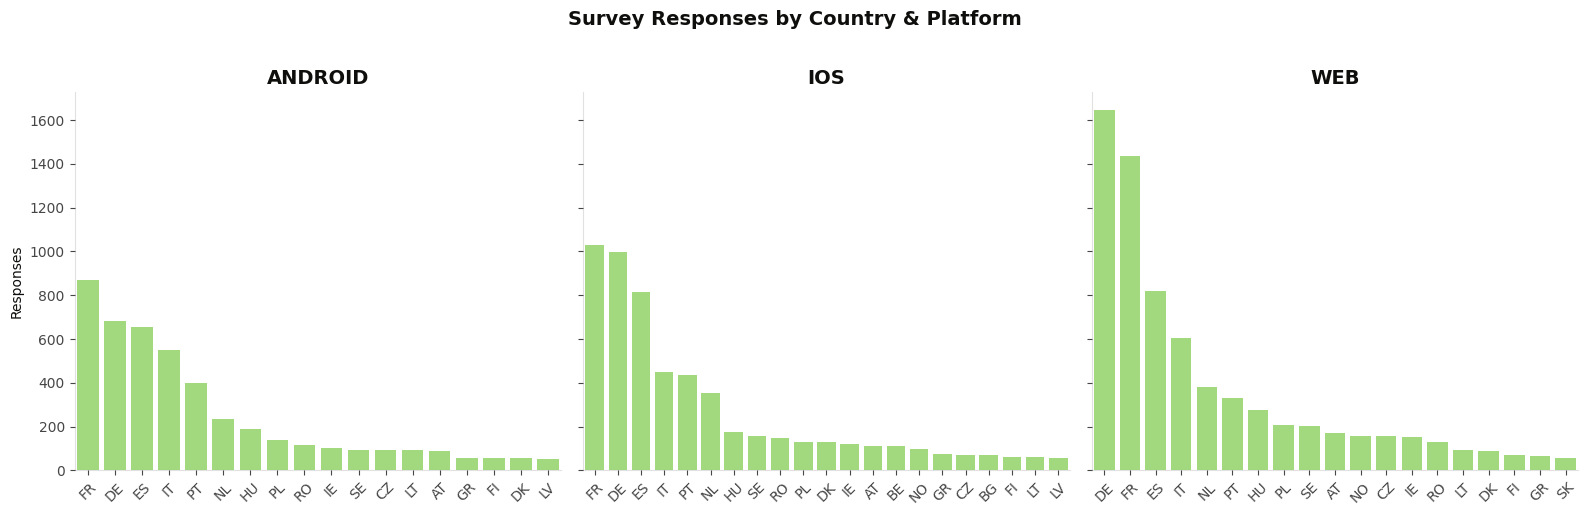

In [41]:
#survey responses by country and platform

country_platform = df[df['PLATFORM'].isin(platforms)].groupby(['REGISTRATION_COUNTRY', 'PLATFORM']).agg(
    responses=('CES_SCORE', 'count')).reset_index()

country_platform = country_platform[country_platform['responses'] > 50]
fig, axes = plt.subplots(1, 3, figsize=(16,5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = country_platform[country_platform['PLATFORM'] == platform].sort_values('responses', ascending=False)

    sns.barplot(x='REGISTRATION_COUNTRY', y='responses', data=data, ax=ax, order=data['REGISTRATION_COUNTRY'])
    ax.set_title(platform)
    ax.set_xlabel('')
    ax.set_ylabel('Responses' if platform == platforms[0] else '')
    ax.tick_params(axis='x', rotation=45)

fig.suptitle('Survey Responses by Country & Platform', fontsize=14, y=1.02)
fig.tight_layout()
plt.show()

Note that the chart shows countries with responses >50 to make the visualisation cleaner. There are ~200 responses in the data across a wide array of other countries. 

Also note that the data was cleaned to remove instances where a user responded to the survey more than once. This removed <1% of responses. 

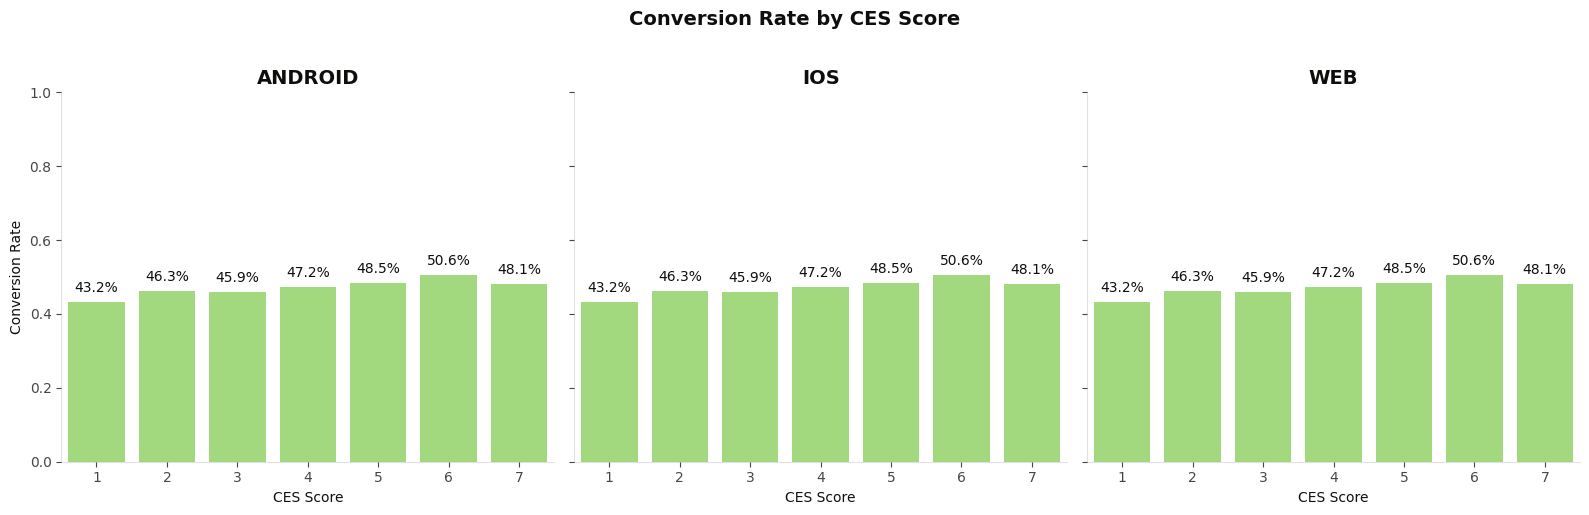

ANDROID: χ²=23.97, df=6, p=0.0005 ***
IOS: χ²=25.90, df=6, p=0.0002 ***
WEB: χ²=12.51, df=6, p=0.0516 ns


In [53]:
#understand if the conversion rate  changes based on CES score
full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna()
platforms = ['ANDROID', 'IOS', 'WEB']

ces_conversion = full_data[full_data['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'CES_SCORE'])['converted'].mean().reset_index()

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = full_data[full_data['PLATFORM'].isin(platforms)].groupby(['PLATFORM', 'CES_SCORE'])['converted'].mean().reset_index()

    sns.barplot(x='CES_SCORE', y='converted', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, errorbar=None)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('Conversion Rate' if ax == axes[0] else '')
    ax.set(ylim=(0, 1))

    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Conversion Rate by CES Score', fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

#chi square test to see if there's a significant association between ces and conversion

platforms = ['ANDROID', 'IOS', 'WEB']
for platform in platforms:
    pdata = full_data[full_data['PLATFORM'] == platform]
    ct = pd.crosstab(pdata['CES_SCORE'], pdata['converted'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: χ²={chi2:.2f}, df={dof}, p={p:.4f} {sig}")

**Insight:** CES score is significantly associated with conversion on Android (p=0.0005) and iOS (p=0.0002), but not on Web (p=0.052). The effect is modest — conversion ranges from ~50% (low CES) to ~60% (high CES) on mobile, while Web is flat at ~35-40% regardless of score.

**Caveats:** This is correlational — users who had an easier experience may both rate higher AND be further along in onboarding. Survivorship bias is also possible: users who churned before completing verification aren't in the transfer data. Further, users who rage quit didn't complete onboarding and didn't take the survey, so this user group with the worst perception of Wise is not in the data.

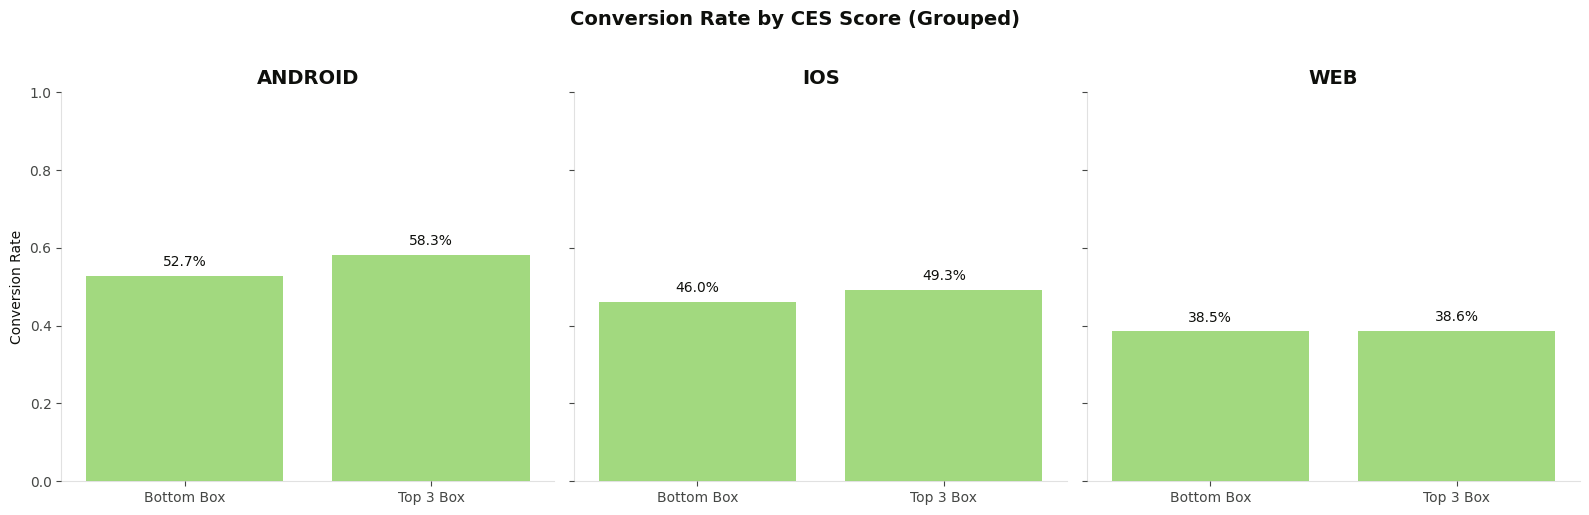

ANDROID: χ²=17.38, df=1, p=0.0000 ***
IOS: χ²=7.76, df=1, p=0.0054 **
WEB: χ²=0.01, df=1, p=0.9291 ns


In [43]:
#look at conversion rate by top 3 box instead of all ces scores, by platform

full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna()
full_data['CES_TOP3'] = full_data['CES_SCORE'].apply(lambda x: 'Top 3 Box' if x >= 5 else ('Bottom Box' if x <= 4 else 'Middle'))
platforms = ['ANDROID', 'IOS', 'WEB']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = full_data[(full_data['PLATFORM'] == platform) & (full_data['CES_TOP3'] != 'Middle')].groupby('CES_TOP3')['converted'].mean().reset_index()

    sns.barplot(x='CES_TOP3', y='converted', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, errorbar=None)
    ax.set_title(platform)
    ax.set_xlabel('')
    ax.set_ylabel('Conversion Rate' if ax == axes[0] else '')
    ax.set(ylim=(0, 1))
    
    for bar in ax.patches:
        ax.annotate(f"{bar.get_height():.1%}", (bar.get_x() + bar.get_width() / 2, bar.get_height()),
                    ha='center', va='bottom', fontsize=10, xytext=(0, 5), textcoords='offset points')

fig.suptitle('Conversion Rate by CES Score (Grouped)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#chi square test to see if there's a significant association between ces and conversion
platforms = ['ANDROID', 'IOS', 'WEB']
for platform in platforms:
    pdata = full_data[(full_data['PLATFORM'] == platform) & (full_data['CES_TOP3'] != 'Middle')]
    ct = pd.crosstab(pdata['CES_TOP3'], pdata['converted'])
    chi2, p, dof, _ = chi2_contingency(ct)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: χ²={chi2:.2f}, df={dof}, p={p:.4f} {sig}")

**Insight:** The top-3-box grouping sharpens the mobile finding — Android (p<0.0001) and iOS (p=0.005) show significantly higher conversion for top-3-box vs bottom-box users. Web remains non-significant (p=0.93).

**Caveat:** The absolute difference is still small (~5-8pp on mobile). The signal is real but the practical magnitude may not justify major investment on its own. That the signal is strengthened with this grouping should lead us to consider whether reducing the granularity of the survey responses would lead to better measurement ability. 

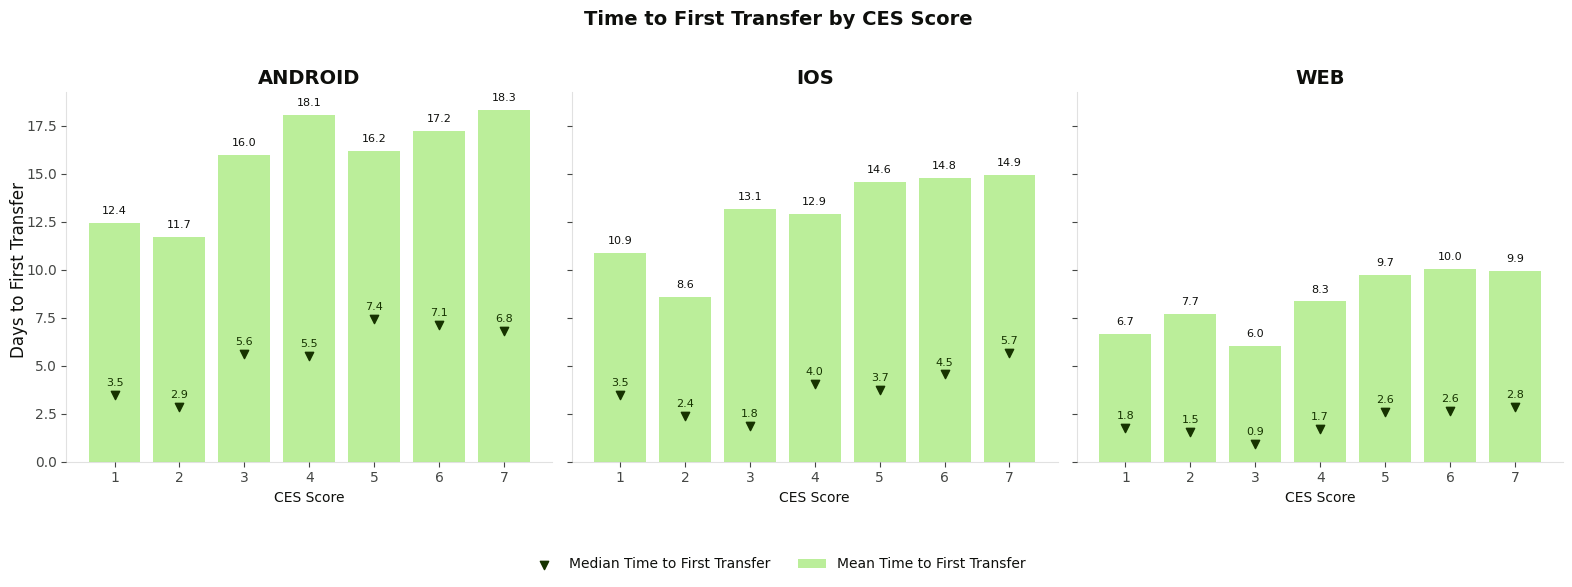

ANDROID: H=28.15, p=0.0001 ***
IOS: H=42.71, p=0.0000 ***
WEB: H=98.32, p=0.0000 ***


In [44]:
#now I want to see if there is an impact on time to first transfer from ces score

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
for ax, platform in zip(axes, platforms):
    data = df[df['PLATFORM'] == platform].groupby('CES_SCORE')['time_to_first_transfer'].agg(['mean', 'median']).reset_index()
    
    ax.bar(data['CES_SCORE'], data['mean'], color=wise_colours.BRIGHT_GREEN, alpha=0.7, label='Mean Time to First Transfer')
    ax.scatter(data['CES_SCORE'], data['median'], color=wise_colours.FOREST_GREEN, marker='v', zorder=3, label='Median Time to First Transfer')
    
    for _, row in data.iterrows():
        ax.annotate(f"{row['mean']:.1f}", (row['CES_SCORE'], row['mean']), ha='center', va='bottom', fontsize=8, xytext=(0, 5), textcoords='offset points')
        ax.annotate(f"{row['median']:.1f}", (row['CES_SCORE'], row['median']), ha='center', va='bottom', fontsize=8, color=wise_colours.FOREST_GREEN, xytext=(0, 5), textcoords='offset points')
    
    ax.set_xlabel('CES Score')
    ax.set_title(platform)
    ax.set_xticks(range(1, 8))

fig.suptitle('Time to First Transfer by CES Score', fontsize=14, y=1.02)
fig.supylabel('Days to First Transfer')
fig.tight_layout()
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2)
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    pdata = df[df['PLATFORM'] == platform]
    groups = [group['time_to_first_transfer'].values for _, group in pdata.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")

**Insight:** Lower CES users tend to transfer *faster*, the opposite of what we'd expect. Multiple explanations are plausible and we cannot distinguish between them with this data:

1. **Motivation bias:** Users with high urgency pushed through a frustrating experience (hence low CES) but their strong intent meant they transferred quickly anyway.
2. **Process-driven:** Slow manual reviews cause both low CES (frustration with wait) and fast first transfer (pent-up intent releases immediately on approval).
3. **Selection:** The fastest converters may have simpler verification paths that still feel effortful on mobile.

The large mean/median gap indicates heavy right-skew driven by a few slow converters. This ambiguity demonstrates the difficulty in using a perception-based metric without process instrumentation to disambiguate.

In [45]:
# Interaction test: does CES only predict repeat transfers for slow-converters?
# If so, we may have two separate populations and the pooled effect is hiding that.

# Build user-level dataset with conversion speed + follow-on count
df_speed = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'REGISTRATION_COUNTRY']
).agg(
    followon_count=('SEND_COUNT', 'sum'),
    time_to_first=('time_to_first_transfer', 'first')
).reset_index()
df_speed['followon_count'] = df_speed['followon_count'] - 1
df_speed = df_speed[df_speed['followon_count'] >= 0].dropna(subset=['REGISTRATION_COUNTRY'])

country_counts_spd = df_speed['REGISTRATION_COUNTRY'].value_counts()
valid_countries_spd = country_counts_spd[country_counts_spd >= 30].index
df_speed = df_speed[df_speed['REGISTRATION_COUNTRY'].isin(valid_countries_spd)]

# Median split on conversion speed
median_time = df_speed['time_to_first'].median()
df_speed['fast_converter'] = (df_speed['time_to_first'] <= median_time).astype(int)

print("=" * 70)
print("INTERACTION TEST: CES × Conversion Speed → Follow-on Transfers")
print("=" * 70)
print(f"\nMedian time to first transfer: {median_time:.1f} days")
print(f"Fast converters (≤ median): n={df_speed['fast_converter'].sum():,}, mean CES={df_speed[df_speed['fast_converter']==1]['CES_SCORE'].mean():.2f}")
print(f"Slow converters (> median): n={(~df_speed['fast_converter'].astype(bool)).sum():,}, mean CES={df_speed[df_speed['fast_converter']==0]['CES_SCORE'].mean():.2f}")

# Interaction model
model_interaction = smf.negativebinomial(
    'followon_count ~ CES_SCORE * fast_converter + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_speed
).fit(maxiter=1000, disp=False)

print(f"\n{'Parameter':<30} {'Coef':>8} {'Rate Ratio':>12} {'p-value':>10} {'Sig':>4}")
print("-" * 70)
for p in ['CES_SCORE', 'fast_converter', 'CES_SCORE:fast_converter']:
    coef = model_interaction.params[p]
    rr = np.exp(coef)
    pval = model_interaction.pvalues[p]
    sig = '***' if pval < 0.001 else '**' if pval < 0.01 else '*' if pval < 0.05 else 'ns'
    print(f"  {p:<28} {coef:>8.4f} {rr:>12.3f} {pval:>10.4f} {sig:>4}")

# Stratified models for interpretability
print(f"\n--- Stratified: CES effect by conversion speed ---")
for group, label in [(1, 'Fast (≤ median)'), (0, 'Slow (> median)')]:
    subset = df_speed[df_speed['fast_converter'] == group]
    m = smf.negativebinomial(
        'followon_count ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
        data=subset
    ).fit(maxiter=1000, disp=False)
    rr = np.exp(m.params['CES_SCORE'])
    p = m.pvalues['CES_SCORE']
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"  {label:<20} (n={len(subset):,}): RR={rr:.3f} ({(rr-1)*100:+.1f}% per CES point), p={p:.4f} {sig}")

# Tertile split for finer granularity
print(f"\n--- Tertile split ---")
df_speed['speed_tertile'] = pd.qcut(df_speed['time_to_first'], 3, labels=['Fast', 'Medium', 'Slow'])
for tertile in ['Fast', 'Medium', 'Slow']:
    subset = df_speed[df_speed['speed_tertile'] == tertile]
    m = smf.negativebinomial(
        'followon_count ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
        data=subset
    ).fit(maxiter=1000, disp=False)
    rr = np.exp(m.params['CES_SCORE'])
    p = m.pvalues['CES_SCORE']
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    time_range = f"[{subset['time_to_first'].min():.0f}-{subset['time_to_first'].max():.0f}d]"
    print(f"  {tertile:<8} {time_range:<15} (n={len(subset):,}): RR={rr:.3f} ({(rr-1)*100:+.1f}%), p={p:.4f} {sig}")

print(f"\n→ Interaction term p={model_interaction.pvalues['CES_SCORE:fast_converter']:.4f}")
if model_interaction.pvalues['CES_SCORE:fast_converter'] > 0.05:
    print("  The CES → repeat transfer effect does NOT differ by conversion speed.")
    print("  These are not two separate populations — the pooled effect is robust.")
else:
    print("  The CES effect DOES differ by conversion speed — investigate further.")


INTERACTION TEST: CES × Conversion Speed → Follow-on Transfers

Median time to first transfer: 3.5 days
Fast converters (≤ median): n=5,105, mean CES=5.36
Slow converters (> median): n=5,104, mean CES=5.70

Parameter                          Coef   Rate Ratio    p-value  Sig
----------------------------------------------------------------------
  CES_SCORE                      0.0724        1.075     0.0000  ***
  fast_converter                -0.2145        0.807     0.0557   ns
  CES_SCORE:fast_converter      -0.0022        0.998     0.9088   ns

--- Stratified: CES effect by conversion speed ---
  Fast (≤ median)      (n=5,105): RR=1.065 (+6.5% per CES point), p=0.0000 ***
  Slow (> median)      (n=5,104): RR=1.077 (+7.7% per CES point), p=0.0000 ***

--- Tertile split ---
  Fast     [0-1d]          (n=3,403): RR=1.067 (+6.7%), p=0.0002 ***
  Medium   [1-10d]         (n=3,403): RR=1.079 (+7.9%), p=0.0000 ***
  Slow     [10-154d]       (n=3,403): RR=1.077 (+7.7%), p=0.0000 ***

→ Int

**Insight:** The interaction between CES and conversion speed is non-significant (p=0.91). The CES → repeat transfer relationship is consistent across fast converters (+6.5% per point), medium converters (+7.9%), and slow converters (+7.7%). These are **not** two separate populations — the pooled 7.9% effect is robust regardless of how quickly users made their first transfer.

This means the timing paradox (lower CES → faster first transfer) and the frequency finding (higher CES → more repeat transfers) are operating on different dimensions. Whatever explains the speed pattern — whether urgency, review delays, or something else — it does not moderate the CES–retention relationship. The repeat transfer signal stands independently.

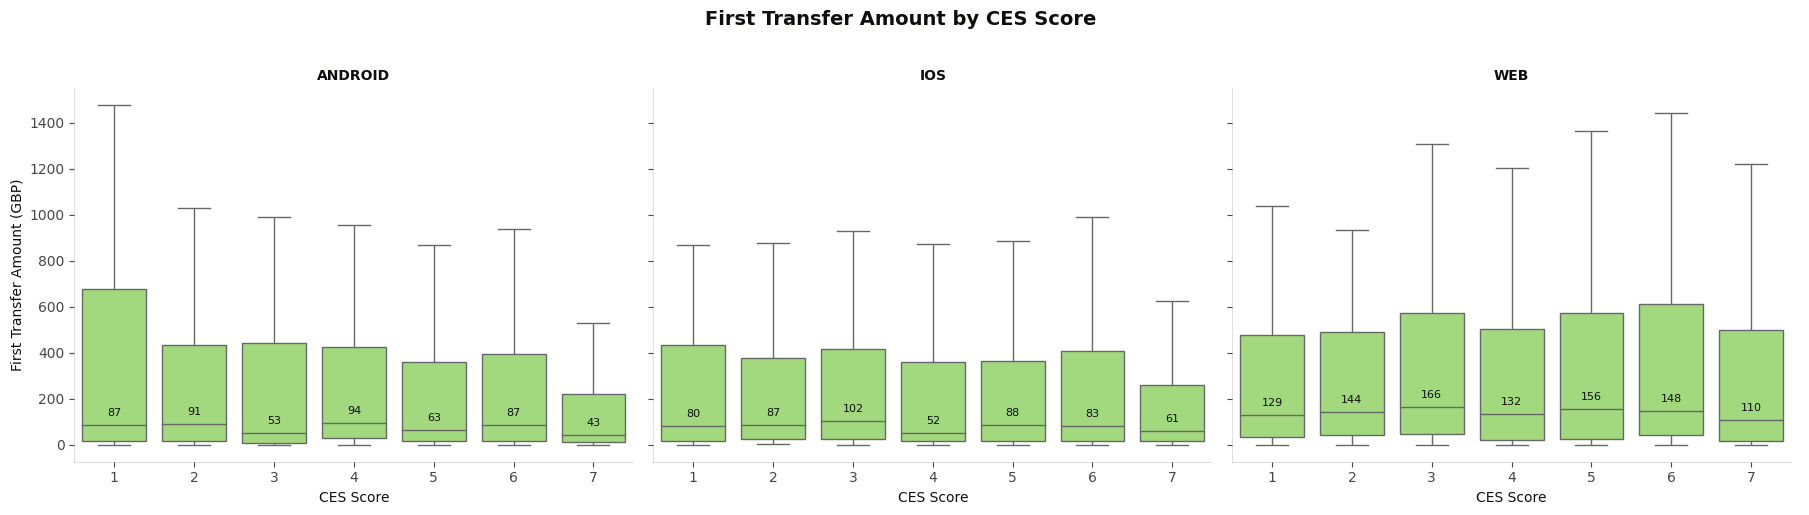

In [46]:
#boxplot showing first transfer amount by ces score and platform

g = sns.catplot(
    data=df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])],
    x='CES_SCORE', y='FIRST_TRANSFER_AMOUNT_GBP', col='PLATFORM',
    kind='box', showfliers=False, height=5, aspect=1.2, color=wise_colours.BRIGHT_GREEN
)
g.set_axis_labels('CES Score', 'First Transfer Amount (GBP)')
g.set_titles('{col_name}')
g.figure.suptitle('First Transfer Amount by CES Score', fontsize=14, y=1.02)

for ax in g.axes.flat:
    for i, box in enumerate(ax.get_xticks()):
        subset = df[(df['PLATFORM'] == ax.get_title()) & (df['CES_SCORE'] == i + 1)]['FIRST_TRANSFER_AMOUNT_GBP']
        if len(subset) > 0:
            median = subset.median()
            ax.annotate(f"{median:.0f}", (i, median), ha='center', va='bottom', fontsize=8, xytext=(0, 5), textcoords='offset points')

plt.tight_layout()
plt.show()

**Insight:** First transfer amounts are similar across CES scores — no meaningful pattern. This suggests that CES captures friction in the verification process, not differences in user wealth or intent to send a particular amount.

**Caveat:** Outliers are hidden (showfliers=False). First transfer amount is also a noisy proxy since users may be testing with a small send regardless of their actual use case, or meeting an urgent need with high motivation. 

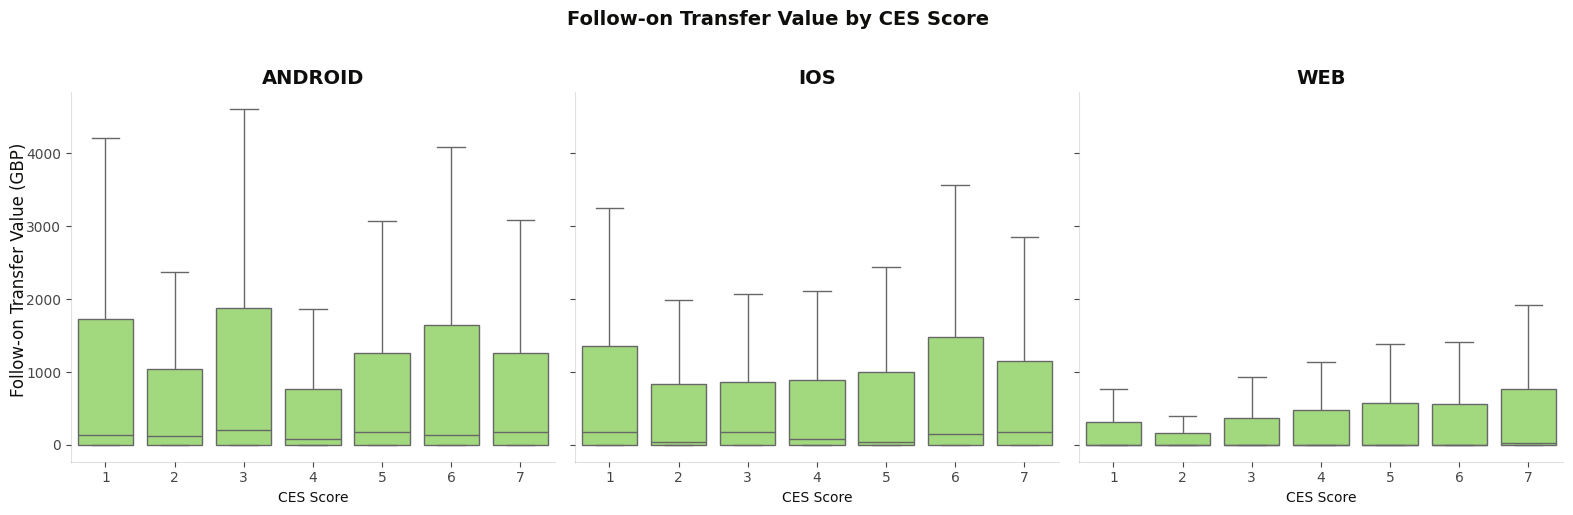

ANDROID: H=5.11, p=0.5298 ns
IOS: H=11.83, p=0.0659 ns
WEB: H=39.45, p=0.0000 ***


In [47]:
# Follow-on transfer value = total spend - first transfer amount
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_VALUE_GBP'].sum().reset_index()

df_followon['followon_value'] = df_followon['SEND_VALUE_GBP'] - df_followon['FIRST_TRANSFER_AMOUNT_GBP']

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_SCORE', y='followon_value', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Value by CES Score', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Value (GBP)')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_value'].values for _, group in data.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")


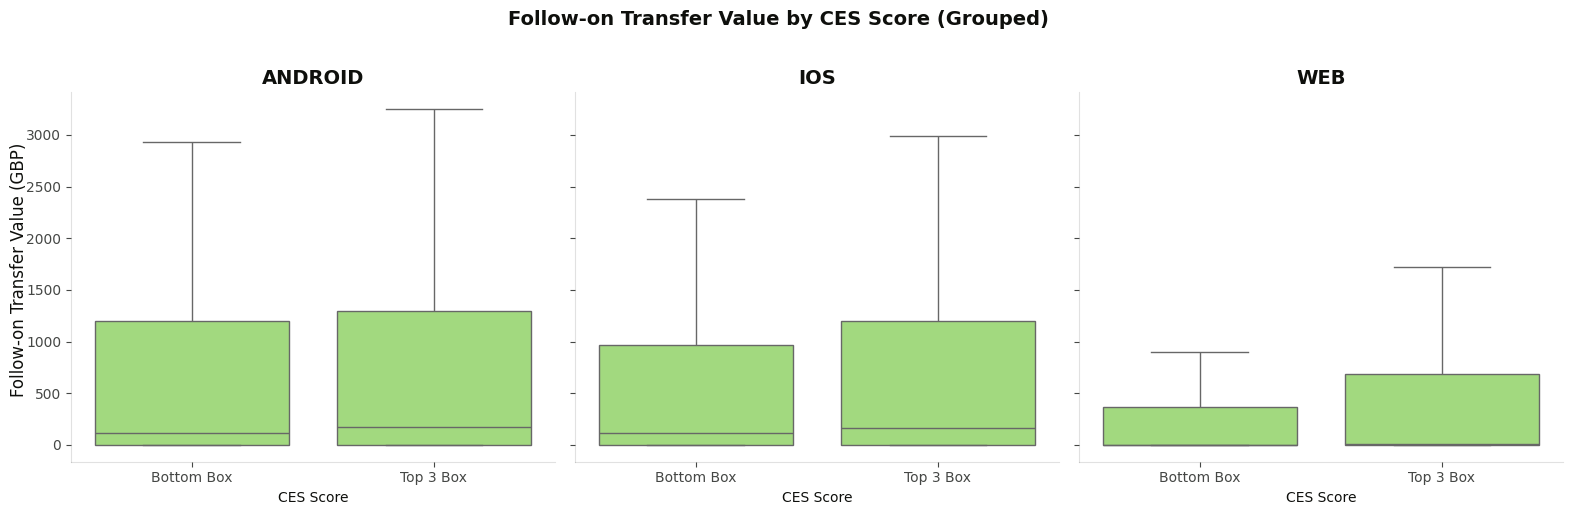

ANDROID: U=451626, p=0.0890 ns
IOS: U=696000, p=0.0871 ns
WEB: U=2761896, p=0.0000 ***


In [48]:
# Follow-on transfer value = total spend - first transfer amount by top 3 box
df['CES_TOP3'] = df['CES_SCORE'].apply(lambda x: 'Top 3 Box' if x >= 5 else ('Bottom Box' if x <=4 else 'Middle'))


df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_TOP3', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_VALUE_GBP'].sum().reset_index()

df_followon['followon_value'] = df_followon['SEND_VALUE_GBP'] - df_followon['FIRST_TRANSFER_AMOUNT_GBP']

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_TOP3', y='followon_value', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False, order=['Bottom Box', 'Top 3 Box'])
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Value by CES Score (Grouped)', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Value (GBP)')
fig.tight_layout()
plt.show()

from scipy.stats import mannwhitneyu

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    top3 = data[data['CES_TOP3'] == 'Top 3 Box']['followon_value']
    bottom_box = data[data['CES_TOP3'] == 'Bottom Box']['followon_value']
    stat, p = mannwhitneyu(top3, bottom_box, alternative='two-sided')
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: U={stat:.0f}, p={p:.4f} {sig}")


**Insight:** Follow-on transfer value does not differ significantly by CES score on mobile (Android p=0.53, iOS p=0.07). Only Web shows a significant difference (p<0.0001). When grouped into top/bottom box, a similar pattern holds — Web shows clear differentiation but mobile platforms do not.

**Caveat:** Transfer value is heavily skewed by a few high-value senders. The signal on Web may be driven by a small number of power users rather than a broad behavioral pattern.

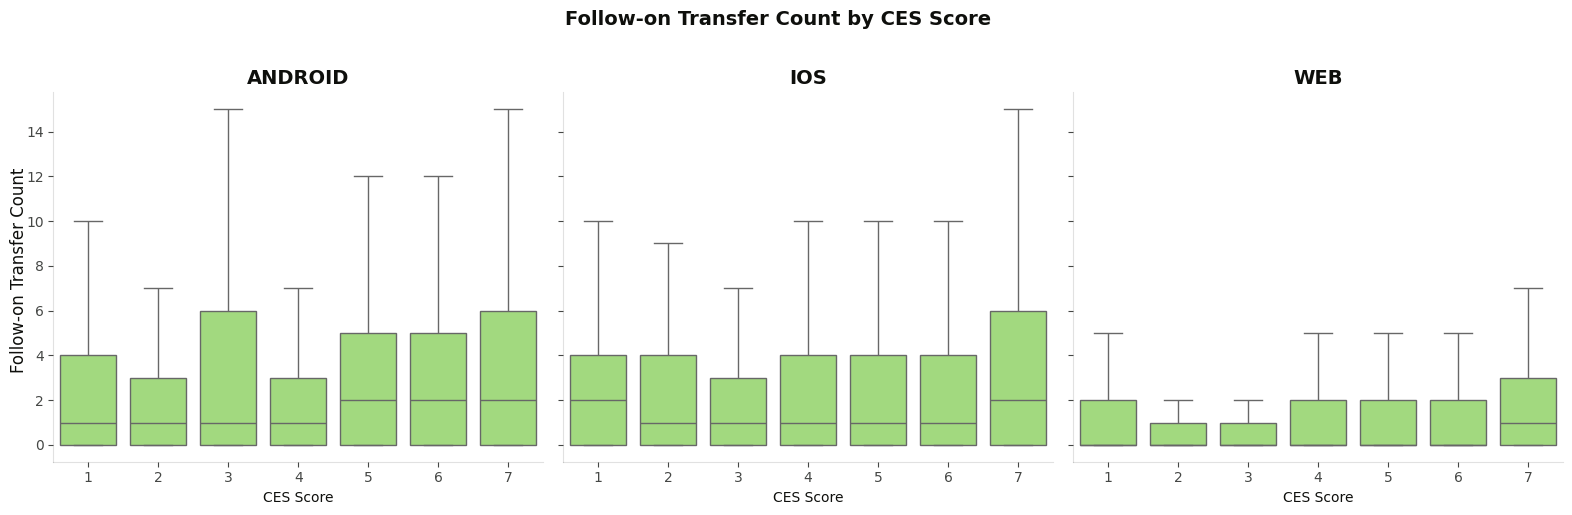

ANDROID: H=20.80, p=0.0020 **
IOS: H=17.44, p=0.0078 **
WEB: H=61.69, p=0.0000 ***


In [49]:
# Follow-on transfer count = total transfers - 1
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_COUNT'].sum().reset_index()

df_followon['followon_count'] = df_followon['SEND_COUNT'] - 1

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_SCORE', y='followon_count', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False)
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Count by CES Score', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Count')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_count'].values for _, group in data.groupby('CES_SCORE')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")


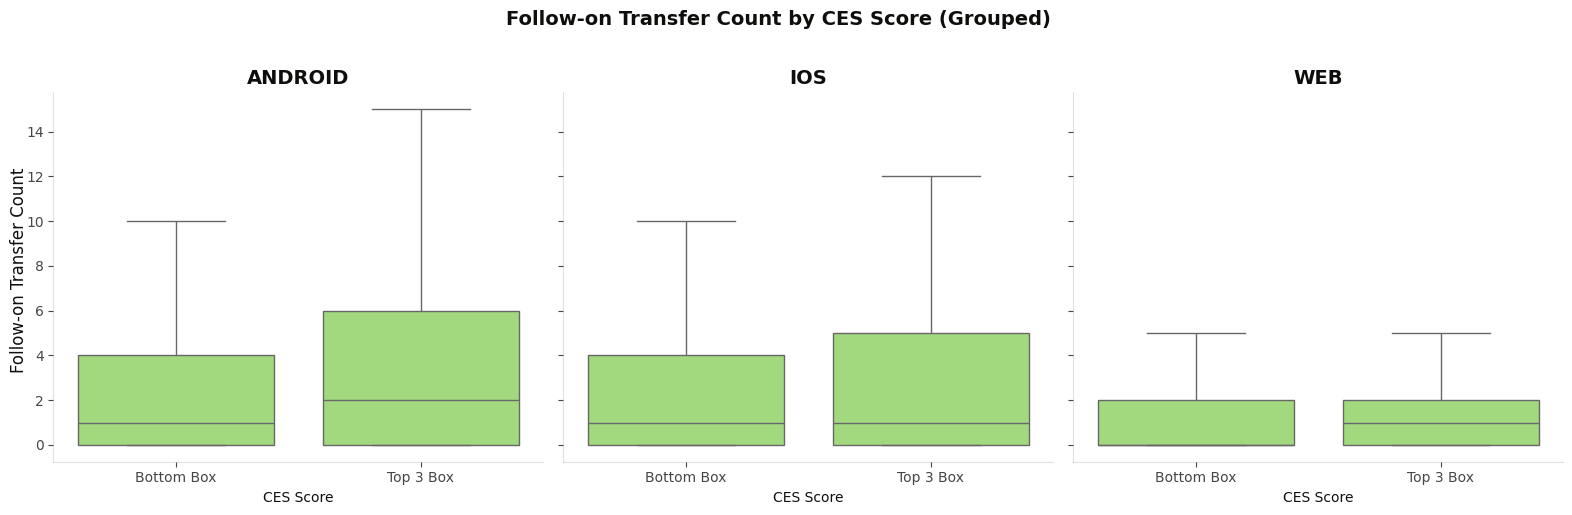

ANDROID: H=16.31, p=0.0001 ***
IOS: H=4.59, p=0.0322 *
WEB: H=29.68, p=0.0000 ***


In [50]:
# Follow-on transfer count = total transfers - 1 by top 3 box
df_followon = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_TOP3', 'FIRST_TRANSFER_AMOUNT_GBP']
)['SEND_COUNT'].sum().reset_index()

df_followon['followon_count'] = df_followon['SEND_COUNT'] - 1

platforms = ['ANDROID', 'IOS', 'WEB']
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, platform in zip(axes, platforms):
    data = df_followon[df_followon['PLATFORM'] == platform]
    
    sns.boxplot(x='CES_TOP3', y='followon_count', data=data, ax=ax, color=wise_colours.BRIGHT_GREEN, showfliers=False, order=['Bottom Box', 'Top 3 Box'])
    ax.set_title(platform)
    ax.set_xlabel('CES Score')
    ax.set_ylabel('')


fig.suptitle('Follow-on Transfer Count by CES Score (Grouped)', fontsize=14, y=1.02)
fig.supylabel('Follow-on Transfer Count')
fig.tight_layout()
plt.show()

from scipy.stats import kruskal

for platform in platforms:
    data = df_followon[df_followon['PLATFORM'] == platform]
    groups = [group['followon_count'].values for _, group in data.groupby('CES_TOP3')]
    stat, p = kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"{platform}: H={stat:.2f}, p={p:.4f} {sig}")

**Insight:** Follow-on transfer **count** is the strongest behavioral signal for CES. It's significant across all platforms (Android p=0.002, iOS p=0.008, Web p<0.0001). Higher CES users make more repeat transfers. The top/bottom box grouping confirms this (all platforms p<0.05).

**Caveat:** This is the most actionable finding, but causality is unclear — users with stronger underlying intent to use Wise may both rate the experience higher and transact more frequently. Country and platform are confounds (addressed in the regression). That being said, this demonstrates that there may be some downstream economic benefit to Wise from improving verification experiences. We would need properly design experimentation and measurement systems and more data to better understand the true effect and drivers of that effect.

In [51]:
#negative binomial regression to predict follow-on transfer count based on ces score, controlling for platform and country
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_reg = df[df['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].groupby(
    ['USER_ID', 'PLATFORM', 'CES_SCORE', 'REGISTRATION_COUNTRY']
)['SEND_COUNT'].sum().reset_index()
df_reg['followon_count'] = df_reg['SEND_COUNT'] - 1
df_reg = df_reg[df_reg['followon_count'] >= 0].dropna(subset=['REGISTRATION_COUNTRY'])
country_counts = df_reg['REGISTRATION_COUNTRY'].value_counts()
valid_countries = country_counts[country_counts >= 30].index
df_reg = df_reg[df_reg['REGISTRATION_COUNTRY'].isin(valid_countries)]




model= smf.negativebinomial(
    'followon_count ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_reg
).fit(maxiter=1000)


print(model.summary().tables[1])
print(f"\nCES_SCORE rate ratio: {np.exp(model.params['CES_SCORE']):.3f}")
print(f"CES_SCORE p-value: {model.pvalues['CES_SCORE']:.4f}")



Optimization terminated successfully.
         Current function value: 2.157915
         Iterations: 131
         Function evaluations: 135
         Gradient evaluations: 135
                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              0.8314      0.137      6.086      0.000       0.564       1.099
C(PLATFORM, Treatment(reference="ANDROID"))[T.IOS]     0.0457      0.049      0.941      0.347      -0.049       0.141
C(PLATFORM, Treatment(reference="ANDROID"))[T.WEB]    -0.8021      0.044    -18.043      0.000      -0.889      -0.715
C(REGISTRATION_COUNTRY)[T.BE]                          0.1134      0.244      0.466      0.642      -0.364       0.591
C(REGISTRATION_COUNTRY)[T.BG]                          0.5142      0.226      2.275      0.023       0.071     

**Insight:** After controlling for platform and country, CES score remains a significant predictor of follow-on transfer count (p<0.0001). Each 1-point CES increase is associated with 7.9% more follow-on transfers (rate ratio=1.079). Web users make significantly fewer follow-on transfers than Android (coef=-0.80), while iOS is not significantly different from Android.

**Caveat:** The model controls for observable confounds but cannot establish causation. Unobserved factors (e.g., user's underlying need to send money regularly) could drive both higher CES and higher transfer frequency. The logistic regression on conversion tells a complementary but weaker story (odds ratio=1.026, ~2.6% increase per CES point).

In [52]:
# Logistic regression: does CES score predict conversion, controlling for platform and country?
full_data['converted'] = full_data['FIRST_TRANSFER_DATE'].notna().astype(int)

df_logit = full_data[full_data['PLATFORM'].isin(['ANDROID', 'IOS', 'WEB'])].dropna(subset=['REGISTRATION_COUNTRY'])

country_counts = df_logit['REGISTRATION_COUNTRY'].value_counts()
valid_countries = country_counts[country_counts >= 30].index
df_logit = df_logit[df_logit['REGISTRATION_COUNTRY'].isin(valid_countries)]

logit_model = smf.glm(
    'converted ~ CES_SCORE + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_logit,
    family=sm.families.Binomial()
).fit(maxiter=1000)

print(logit_model.summary().tables[1])
print(f"\nCES_SCORE odds ratio: {np.exp(logit_model.params['CES_SCORE']):.3f}")
print(f"CES_SCORE p-value: {logit_model.pvalues['CES_SCORE']:.4f}")


                                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------------------------
Intercept                                              0.3920      0.084      4.692      0.000       0.228       0.556
C(PLATFORM, Treatment(reference="ANDROID"))[T.IOS]    -0.3644      0.029    -12.543      0.000      -0.421      -0.307
C(PLATFORM, Treatment(reference="ANDROID"))[T.WEB]    -0.7796      0.027    -28.887      0.000      -0.832      -0.727
C(REGISTRATION_COUNTRY)[T.BE]                         -0.4029      0.145     -2.775      0.006      -0.687      -0.118
C(REGISTRATION_COUNTRY)[T.BG]                         -0.1747      0.137     -1.277      0.202      -0.443       0.093
C(REGISTRATION_COUNTRY)[T.CY]                         -0.7413      0.161     -4.604      0.000      -1.057      -0.426
C(REGISTRATION_COUNTRY)[T.CZ]                   

## Appendix: Analysis of measurement tool

IRT analysis on scale, ordinal logit testing, AIC comparison for 7 vs 3 level negative binomial regression

- **Discrimination is moderate (~1.26)** and similar across platforms
- **Significant DIF (p<0.001)** — mobile vs web users do interpret the scale differently (mobile thresholds are shifted lower, meaning mobile users give higher scores for the same latent friction)
- **Some low-end bunching** (b1-b2 gaps around 0.30-0.36), but not severe
- **7-level model has slightly better AIC than the 3-level collapse**, so the continuous regression driving the 7.9% figure remains the stronger specification — but the effect sizes in the 3-level model are more interpretable (High=42% more transfers vs Low)

In [35]:
#irt
# Graded Response Model (GRM) IRT analysis on CES 7-point scale
# Determines how well each CES point differentiates between users with
# different levels of verification friction across platforms
# Note: Claude did this. I checked for errors and ensuring the right data is being used, but this is a complex implementation so would recommend reviewing carefully 


from scipy.optimize import minimize
from scipy.special import expit
from scipy.stats import chi2
from matplotlib.gridspec import GridSpec
from statsmodels.miscmodels.ordinal_model import OrderedModel

platforms_irt = ['ANDROID', 'IOS', 'WEB']
df_irt = full_data[full_data['PLATFORM'].isin(platforms_irt)].copy()
df_irt['CES_SCORE_0'] = df_irt['CES_SCORE'] - 1  # 0-index for GRM

# --- Vectorized GRM fitting via marginal MLE with Gauss-Hermite quadrature ---

N_QUAD = 41
THETA_POINTS = np.linspace(-4, 4, N_QUAD)
QUAD_WEIGHTS = np.exp(-THETA_POINTS**2 / 2) / np.sqrt(2 * np.pi)
QUAD_WEIGHTS /= QUAD_WEIGHTS.sum()

def grm_neg_ll(params, responses, n_cat=7):
    """Vectorized negative log-likelihood for a single-item GRM."""
    a = np.exp(params[0])
    b = np.sort(params[1:n_cat])
    
    # P*(theta, bk) for all quadrature points and thresholds
    cum_inner = expit(a * (THETA_POINTS[:, None] - b[None, :]))  # (n_quad, n_thresh)
    
    # Full cumulative: P*(0)=1, P*(1..6)=cum_inner, P*(7)=0
    cum_full = np.ones((N_QUAD, n_cat + 1))
    cum_full[:, 1:n_cat] = cum_inner
    cum_full[:, -1] = 0.0
    
    # Category probs P(X=k) = P*(k) - P*(k+1)
    cat_probs = np.maximum(cum_full[:, :-1] - cum_full[:, 1:], 1e-10)  # (n_quad, n_cat)
    
    # Likelihood per respondent marginalised over theta
    resp_probs = cat_probs[:, responses.astype(int)]  # (n_quad, n_resp)
    marginal = (QUAD_WEIGHTS[:, None] * resp_probs).sum(axis=0)
    
    return -np.log(np.maximum(marginal, 1e-10)).sum()

def fit_grm(responses, n_cat=7):
    """Fit single-item GRM. Returns (discrimination, thresholds, neg_ll)."""
    n_thresh = n_cat - 1
    # Initialise thresholds from cumulative proportions
    props = np.array([(responses <= k).mean() for k in range(n_thresh)])
    props = np.clip(props, 0.01, 0.99)
    b_init = -np.log(1/props - 1)
    x0 = np.concatenate([[np.log(1.5)], b_init])
    
    result = minimize(grm_neg_ll, x0, args=(responses, n_cat),
                      method='L-BFGS-B', options={'maxiter': 5000, 'ftol': 1e-10})
    a = np.exp(result.x[0])
    b = np.sort(result.x[1:n_cat])
    return a, b, result.fun

# --- Fit per platform ---
print("=" * 70)
print("GRADED RESPONSE MODEL — CES 7-point scale by platform")
print("=" * 70)

grm_results = {}
for platform in platforms_irt:
    responses = df_irt[df_irt['PLATFORM'] == platform]['CES_SCORE_0'].values
    a, b, nll = fit_grm(responses)
    grm_results[platform] = {'a': a, 'b': b, 'n': len(responses), 'nll': nll}
    print(f"\n{platform} (n={len(responses):,})")
    print(f"  Discrimination (a): {a:.3f}")
    print(f"  Thresholds (b1→b6): {', '.join(f'{x:.3f}' for x in b)}")
    gaps = [b[i+1] - b[i] for i in range(len(b)-1)]
    print(f"  Threshold gaps:     {', '.join(f'{g:.3f}' for g in gaps)}")
    bunched = [i+1 for i, g in enumerate(gaps) if abs(g) < 0.3]
    if bunched:
        print(f"  ⚠ Bunched thresholds between categories: {bunched}")

# --- Also fit combined (all platforms) for DIF baseline ---
responses_all = df_irt['CES_SCORE_0'].values
a_all, b_all, nll_all = fit_grm(responses_all)
grm_results['ALL'] = {'a': a_all, 'b': b_all, 'n': len(responses_all), 'nll': nll_all}
print(f"\nCOMBINED (n={len(responses_all):,})")
print(f"  Discrimination (a): {a_all:.3f}")
print(f"  Thresholds (b1→b6): {', '.join(f'{x:.3f}' for x in b_all)}")


GRADED RESPONSE MODEL — CES 7-point scale by platform

ANDROID (n=8,449)
  Discrimination (a): 1.260
  Thresholds (b1→b6): -2.842, -2.478, -2.018, -1.379, -0.592, 0.117
  Threshold gaps:     0.364, 0.460, 0.639, 0.787, 0.708

IOS (n=12,120)
  Discrimination (a): 1.257
  Thresholds (b1→b6): -2.852, -2.550, -2.154, -1.496, -0.830, -0.169
  Threshold gaps:     0.302, 0.395, 0.659, 0.665, 0.662

WEB (n=19,127)
  Discrimination (a): 1.302
  Thresholds (b1→b6): -2.285, -1.936, -1.523, -1.009, -0.344, 0.348
  Threshold gaps:     0.349, 0.413, 0.515, 0.664, 0.692

COMBINED (n=39,696)
  Discrimination (a): 1.281
  Thresholds (b1→b6): -2.542, -2.204, -1.791, -1.222, -0.538, 0.142


How to read these plots:

CATEGORY RESPONSE CURVES (top row):
  - Each coloured line represents one CES response option (1-7).
  - The x-axis (θ) is the latent trait: how easy verification actually was for
    that user. Left = high friction, right = low friction.
  - Each curve shows the probability of selecting that response at a given θ.
  - A well-functioning scale point has a clear peak: there's a region of θ where
    it's the most likely response. If two curves overlap heavily or a curve never
    becomes dominant, those categories are not differentiating well.
  - Wide, well-separated peaks = the scale is discriminating across the full range.
    Narrow, bunched peaks = several response options are measuring the same thing.

TEST INFORMATION CURVES (bottom row):
  - Shows how much measurement precision the CES item provides at each θ level.
  - Higher information = more precision (smaller standard error of measurement).
  - A broad, flat curve means the scale measures well acro

/var/folders/1h/w4xhw7bx50xfvy_jpdv3p41h0000gp/T/ipykernel_19746/3782679691.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


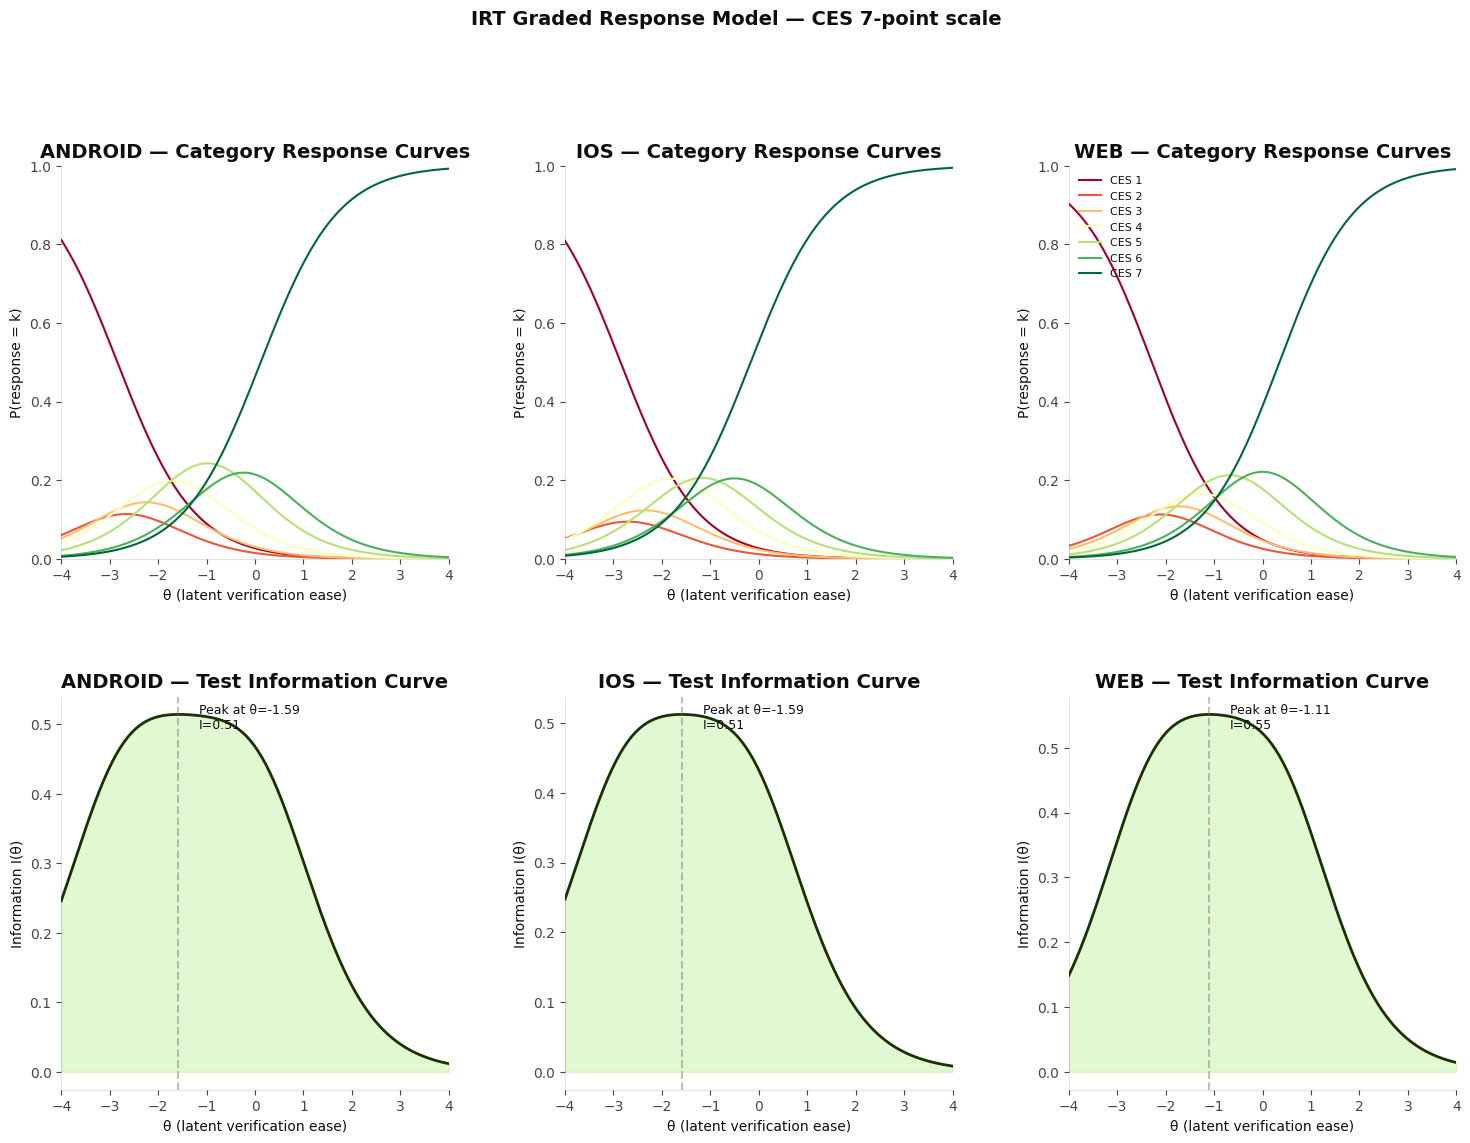

In [36]:
# Item Characteristic Curves (ICCs) and Test Information Curves by platform

print("""How to read these plots:

CATEGORY RESPONSE CURVES (top row):
  - Each coloured line represents one CES response option (1-7).
  - The x-axis (θ) is the latent trait: how easy verification actually was for
    that user. Left = high friction, right = low friction.
  - Each curve shows the probability of selecting that response at a given θ.
  - A well-functioning scale point has a clear peak: there's a region of θ where
    it's the most likely response. If two curves overlap heavily or a curve never
    becomes dominant, those categories are not differentiating well.
  - Wide, well-separated peaks = the scale is discriminating across the full range.
    Narrow, bunched peaks = several response options are measuring the same thing.

TEST INFORMATION CURVES (bottom row):
  - Shows how much measurement precision the CES item provides at each θ level.
  - Higher information = more precision (smaller standard error of measurement).
  - A broad, flat curve means the scale measures well across a wide range of users.
  - A narrow spike means it only discriminates well in one region (e.g., only
    distinguishing moderately-frustrated from slightly-frustrated users, but not
    among the very satisfied or very dissatisfied).
  - The peak location tells you WHERE on the friction spectrum CES is most useful.
""")

theta = np.linspace(-4, 4, 200)

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(2, 3, figure=fig, hspace=0.35, wspace=0.3)

# --- Row 1: Category Response Curves (ICCs) per platform ---
for col, platform in enumerate(platforms_irt):
    ax = fig.add_subplot(gs[0, col])
    a = grm_results[platform]['a']
    b = grm_results[platform]['b']
    
    # Cumulative probabilities
    cum = np.ones((len(theta), 8))
    cum[:, -1] = 0.0
    for k in range(6):
        cum[:, k+1] = expit(a * (theta[:, None] - b[None, :]))[:, k]
    
    # Category probabilities
    cat_probs = cum[:, :-1] - cum[:, 1:]
    
    colours = plt.cm.RdYlGn(np.linspace(0, 1, 7))
    for k in range(7):
        ax.plot(theta, cat_probs[:, k], color=colours[k], linewidth=1.5, 
                label=f'CES {k+1}')
    
    ax.set_title(f'{platform} — Category Response Curves')
    ax.set_xlabel('θ (latent verification ease)')
    ax.set_ylabel('P(response = k)')
    ax.set_xlim(-4, 4)
    ax.set_ylim(0, 1)
    if col == 2:
        ax.legend(fontsize=8, loc='upper left', ncol=1)

# --- Row 2: Test Information Curves per platform ---
for col, platform in enumerate(platforms_irt):
    ax = fig.add_subplot(gs[1, col])
    a = grm_results[platform]['a']
    b = grm_results[platform]['b']
    
    # Information = sum of (P'(k))^2 / P(k) for each category
    cum = np.ones((len(theta), 8))
    cum[:, -1] = 0.0
    for k in range(6):
        cum[:, k+1] = expit(a * (theta[:, None] - b[None, :]))[:, k]
    
    cat_probs = np.maximum(cum[:, :-1] - cum[:, 1:], 1e-10)
    
    # Derivative of P*(k) = a * P*(k) * (1 - P*(k))
    cum_deriv = np.zeros_like(cum)
    for k in range(6):
        cum_deriv[:, k+1] = a * cum[:, k+1] * (1 - cum[:, k+1])
    
    cat_deriv = cum_deriv[:, :-1] - cum_deriv[:, 1:]
    info = np.sum(cat_deriv**2 / cat_probs, axis=1)
    
    ax.plot(theta, info, color=wise_colours.FOREST_GREEN, linewidth=2)
    ax.fill_between(theta, 0, info, color=wise_colours.BRIGHT_GREEN, alpha=0.3)
    ax.set_title(f'{platform} — Test Information Curve')
    ax.set_xlabel('θ (latent verification ease)')
    ax.set_ylabel('Information I(θ)')
    ax.set_xlim(-4, 4)
    
    # Mark peak
    peak_idx = np.argmax(info)
    ax.axvline(theta[peak_idx], color='grey', linestyle='--', alpha=0.5)
    ax.annotate(f'Peak at θ={theta[peak_idx]:.2f}\nI={info[peak_idx]:.2f}',
                (theta[peak_idx], info[peak_idx]),
                xytext=(15, -10), textcoords='offset points', fontsize=9)

fig.suptitle('IRT Graded Response Model — CES 7-point scale', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


DIFFERENTIAL ITEM FUNCTIONING — Mobile vs Web

Mobile (n=20,569): a=1.258, thresholds=['-2.85', '-2.52', '-2.10', '-1.45', '-0.73', '-0.05']
Web    (n=19,127): a=1.302, thresholds=['-2.28', '-1.94', '-1.52', '-1.01', '-0.34', '0.35']

Likelihood Ratio test:
  χ²(7) = 555.96, p = 0.000000 ***

→ Significant DIF detected: mobile and web users interpret the CES scale differently.
  Discrimination: mobile=1.258 vs web=1.302 (ratio=0.97)
  Threshold shifts (mobile - web):
    b1: -0.563 ← notable
    b2: -0.584 ← notable
    b3: -0.574 ← notable
    b4: -0.438 ← notable
    b5: -0.386 ← notable
    b6: -0.399 ← notable


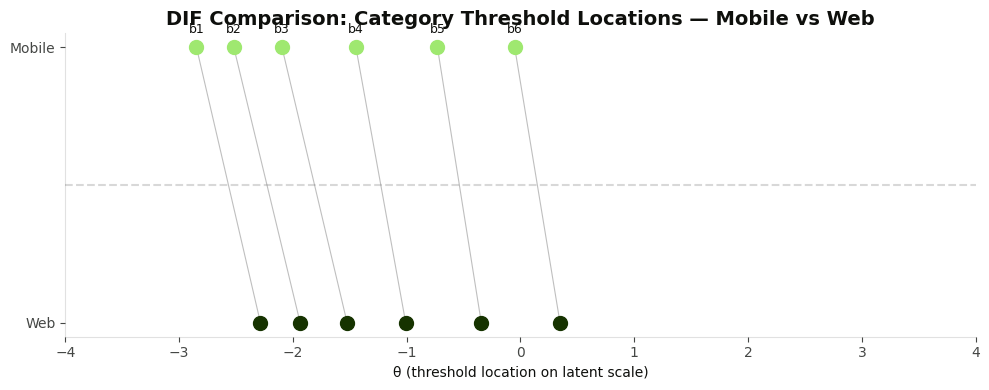

In [37]:
# Differential Item Functioning (DIF): Do mobile vs web users interpret the scale differently?
# Likelihood ratio test: compare constrained (same params) vs free (separate params) model

print("=" * 70)
print("DIFFERENTIAL ITEM FUNCTIONING — Mobile vs Web")
print("=" * 70)

# Mobile = ANDROID + iOS combined
mobile_responses = df_irt[df_irt['PLATFORM'].isin(['ANDROID', 'IOS'])]['CES_SCORE_0'].values
web_responses = df_irt[df_irt['PLATFORM'] == 'WEB']['CES_SCORE_0'].values

a_mob, b_mob, nll_mob = fit_grm(mobile_responses)
a_web, b_web, nll_web = fit_grm(web_responses)

# Combined (constrained) model
combined_responses = np.concatenate([mobile_responses, web_responses])
a_comb, b_comb, nll_comb = fit_grm(combined_responses)

# LR test: 2*(LL_free - LL_constrained)
# Free model has 7 params per group (1 discrim + 6 thresh) * 2 = 14
# Constrained has 7 params
# df = 14 - 7 = 7
lr_stat = 2 * (nll_comb - (nll_mob + nll_web))
dif_df = 7
dif_p = 1 - chi2.cdf(lr_stat, dif_df)

print(f"\nMobile (n={len(mobile_responses):,}): a={a_mob:.3f}, thresholds={[f'{x:.2f}' for x in b_mob]}")
print(f"Web    (n={len(web_responses):,}): a={a_web:.3f}, thresholds={[f'{x:.2f}' for x in b_web]}")
print(f"\nLikelihood Ratio test:")
print(f"  χ²({dif_df}) = {lr_stat:.2f}, p = {dif_p:.6f} {'***' if dif_p < 0.001 else '**' if dif_p < 0.01 else '*' if dif_p < 0.05 else 'ns'}")

if dif_p < 0.05:
    print(f"\n→ Significant DIF detected: mobile and web users interpret the CES scale differently.")
    print(f"  Discrimination: mobile={a_mob:.3f} vs web={a_web:.3f} (ratio={a_mob/a_web:.2f})")
    print(f"  Threshold shifts (mobile - web):")
    for i, (m, w) in enumerate(zip(b_mob, b_web)):
        shift = m - w
        print(f"    b{i+1}: {shift:+.3f} {'← notable' if abs(shift) > 0.3 else ''}")
else:
    print(f"\n→ No significant DIF: platforms interpret the scale similarly.")

# Visualise DIF — overlay threshold locations
fig, ax = plt.subplots(figsize=(10, 4))
y_mob = 1
y_web = 0

for i, (m, w) in enumerate(zip(b_mob, b_web)):
    ax.scatter(m, y_mob, color=wise_colours.BRIGHT_GREEN, s=100, zorder=3)
    ax.scatter(w, y_web, color=wise_colours.FOREST_GREEN, s=100, zorder=3)
    ax.plot([m, w], [y_mob, y_web], color='grey', linewidth=0.8, alpha=0.5)
    ax.annotate(f'b{i+1}', (m, y_mob), xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9)

ax.set_yticks([0, 1])
ax.set_yticklabels(['Web', 'Mobile'])
ax.set_xlabel('θ (threshold location on latent scale)')
ax.set_title('DIF Comparison: Category Threshold Locations — Mobile vs Web')
ax.axhline(0.5, color='grey', linestyle='--', alpha=0.3)
ax.set_xlim(-4, 4)
plt.tight_layout()
plt.show()


In [38]:
# If thresholds are bunched → re-run with ordinal logit on collapsed 3-level CES
# This tests whether the 7-point scale has more granularity than the construct warrants

# Determine if bunching exists (any gap < 0.3 on the combined model)
gaps_all = [b_all[i+1] - b_all[i] for i in range(len(b_all)-1)]
has_bunching = any(abs(g) < 0.3 for g in gaps_all)

print("=" * 70)
print("ORDINAL LOGIT — Collapsed 3-level CES (Low / Mid / High)")
print("=" * 70)

if has_bunching:
    print(f"\n✓ Threshold bunching confirmed (gaps: {[f'{g:.3f}' for g in gaps_all]})")
    print("  → Collapsing to 3 levels: Low (1-3), Mid (4-5), High (6-7)")
else:
    print(f"\n⚠ No clear bunching (gaps: {[f'{g:.3f}' for g in gaps_all]})")
    print("  → Running ordinal logit anyway for comparison")

# Collapse CES to 3 levels
df_irt['CES_3LEVEL'] = pd.cut(
    df_irt['CES_SCORE'], bins=[0, 3, 5, 7], labels=['Low', 'Mid', 'High']
)

# Prepare data for ordinal logit
df_ord = df_irt.dropna(subset=['REGISTRATION_COUNTRY']).copy()
df_ord['converted'] = df_ord['FIRST_TRANSFER_DATE'].notna().astype(int)
country_counts_ord = df_ord['REGISTRATION_COUNTRY'].value_counts()
valid_countries_ord = country_counts_ord[country_counts_ord >= 30].index
df_ord = df_ord[df_ord['REGISTRATION_COUNTRY'].isin(valid_countries_ord)]

# Ordinal logit: Does platform predict CES category?
# Tests whether mobile vs web users systematically differ in CES response patterns
print("\n--- Ordinal Logit: Does platform predict CES category? ---")
df_ord['CES_3LEVEL_code'] = df_ord['CES_3LEVEL'].cat.codes  # 0=Low, 1=Mid, 2=High
df_ord['is_mobile'] = df_ord['PLATFORM'].isin(['ANDROID', 'IOS']).astype(int)

ord_model = OrderedModel(
    df_ord['CES_3LEVEL_code'],
    df_ord[['is_mobile']],
    distr='logit'
)
ord_result = ord_model.fit(method='bfgs', disp=False)
print(ord_result.summary())

# Compare: 7-level vs 3-level CES for predicting follow-on transfers
print("\n--- Model comparison: 7-level vs 3-level CES predicting follow-on transfers ---")

df_reg3_agg = df_ord[df_ord['FIRST_TRANSFER_DATE'].notna()].groupby(
    ['USER_ID', 'PLATFORM', 'CES_3LEVEL', 'REGISTRATION_COUNTRY']
)['SEND_COUNT'].sum().reset_index()
df_reg3_agg['followon_count'] = df_reg3_agg['SEND_COUNT'] - 1
df_reg3_agg = df_reg3_agg[df_reg3_agg['followon_count'] >= 0]

model_3level = smf.negativebinomial(
    'followon_count ~ C(CES_3LEVEL, Treatment(reference="Low")) + C(PLATFORM, Treatment(reference="ANDROID")) + C(REGISTRATION_COUNTRY)',
    data=df_reg3_agg
).fit(maxiter=1000, disp=False)

print("\n  3-level CES model (Low/Mid/High):")
ces_params = {k: v for k, v in model_3level.params.items() if 'CES' in k}
ces_pvals = {k: v for k, v in model_3level.pvalues.items() if 'CES' in k}
for k in ces_params:
    rr = np.exp(ces_params[k])
    p = ces_pvals[k]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    print(f"    {k}: coef={ces_params[k]:.4f}, rate ratio={rr:.3f}, p={p:.4f} {sig}")

print(f"\n  Original 7-level model: CES rate ratio = 1.079, p < 0.0001")
print(f"  AIC comparison: 7-level={model.aic:.1f} vs 3-level={model_3level.aic:.1f}")

if model_3level.aic < model.aic:
    print("  → 3-level model has LOWER AIC (better fit with fewer parameters)")
    print("    This supports collapsing the scale.")
else:
    print("  → 7-level model has lower AIC (retains useful information)")
    print("    The continuous regression remains the stronger specification.")

# Summary
print("\n" + "=" * 70)
print("IRT ANALYSIS SUMMARY")
print("=" * 70)
print("""
Key findings:
1. GRADED RESPONSE MODEL: The discrimination parameter shows how well CES 
   differentiates users at each level. Threshold gaps reveal where the scale
   fails to distinguish between adjacent response options.

2. INFORMATION CURVES: Show the θ-range where CES provides the most measurement
   precision. If information is concentrated narrowly, the scale over-differentiates
   in one region and under-differentiates elsewhere.

3. DIF: Tests whether the same CES score means the same thing on mobile vs web.
   Significant DIF means platform-specific norms should be used when comparing.

4. SCALE COLLAPSE: If thresholds bunch together in the middle of the scale,
   the 7-point version adds noise rather than signal. A 3-level collapse
   (Low/Mid/High) may be psychometrically cleaner for this population.
""")


ORDINAL LOGIT — Collapsed 3-level CES (Low / Mid / High)

⚠ No clear bunching (gaps: ['0.338', '0.413', '0.569', '0.684', '0.680'])
  → Running ordinal logit anyway for comparison

--- Ordinal Logit: Does platform predict CES category? ---
                             OrderedModel Results                             
Dep. Variable:        CES_3LEVEL_code   Log-Likelihood:                -35497.
Model:                   OrderedModel   AIC:                         7.100e+04
Method:            Maximum Likelihood   BIC:                         7.103e+04
Date:                Fri, 22 May 2026                                         
Time:                        14:14:05                                         
No. Observations:               39351                                         
Df Residuals:                   39348                                         
Df Model:                           1                                         
                 coef    std err          z      

### Full query used for collecting data:

```sql
WITH ces_responses AS (
    -- Web (from INT_FEATURE_FEEDBACK)
    SELECT DISTINCT 
        USER_ID AS user_id,
        SCORE AS ces_score,
        COMMENT AS ces_comment,
        CAST(MESSAGE_TIMESTAMP AS DATE) AS survey_date,
        PLATFORM AS platform,
        'WEB' AS source_table
    FROM ANALYTICS_DB.RPT_PRODUCT.INT_FEATURE_FEEDBACK
    WHERE FEATURE_NAME = 'CONSUMER_ONBOARDING_FLOW_DROP_OFF_CUSTOMER_EFFORT_SCORE'
      AND ADDITIONAL_DROP_OFF_STEP = 'VERIFICATION_FLOW'

    UNION ALL

    -- Mobile (from INT_FEEDBACK_UPDATED)
    SELECT DISTINCT
        USER_ID AS user_id,
        FEEDBACK_SCORE AS ces_score,
        FEEDBACK_COMMENT AS ces_comment,
        CAST(SUBMITTED_AT AS DATE) AS survey_date,
        CLIENT_PLATFORM AS platform,
        'MOBILE' AS source_table
    FROM ANALYTICS_DB.RPT_PRODUCT.INT_FEEDBACK_UPDATED
    WHERE SURVEY = 'CONSUMER_ONBOARDING_FLOW_DROP_OFF_CUSTOMER_EFFORT_SCORE'
      AND FEEDBACK_DROP_OFF_STEP = 'VERIFICATION_FLOW'
      AND FEEDBACK_SCORE IS NOT NULL
),
first_transfer AS (
    SELECT 
        t.USER_ID,
        MIN(t.TRANSFER_CREATION_TIME) AS first_transfer_date,
        MIN_BY(t.INVOICE_VALUE_GBP, t.TRANSFER_CREATION_TIME) AS first_transfer_amount_gbp,
        MIN_BY(t.SOURCE_CURRENCY, t.TRANSFER_CREATION_TIME) AS first_transfer_source_currency,
        MIN_BY(t.INVOICE_VALUE, t.TRANSFER_CREATION_TIME) AS first_transfer_amount_source
    FROM ANALYTICS_DB.RPT_PRODUCT.LOOKUP_TRANSFER_CONTEXT t
    INNER JOIN ces_responses c ON t.USER_ID = c.user_id
    WHERE t.SUCCESSFUL_TRANSFER = TRUE
      AND t.TRANSFER_CREATION_TIME >= c.survey_date
    GROUP BY t.USER_ID
),
monthly_sends AS (
    SELECT 
        t.USER_ID,
        DATE_TRUNC('month', t.TRANSFER_CREATION_TIME)::DATE AS send_month,
        COUNT(*) AS send_count,
        SUM(t.INVOICE_VALUE_GBP) AS send_value_gbp
    FROM ANALYTICS_DB.RPT_PRODUCT.LOOKUP_TRANSFER_CONTEXT t
    INNER JOIN ces_responses c ON t.USER_ID = c.user_id
    WHERE t.SUCCESSFUL_TRANSFER = TRUE
      AND t.TRANSFER_CREATION_TIME >= c.survey_date
    GROUP BY t.USER_ID, DATE_TRUNC('month', t.TRANSFER_CREATION_TIME)::DATE
),
user_country AS (
    SELECT USER_ID, REGISTRATION_COUNTRY
    FROM ANALYTICS_DB.RPT_PRODUCT.ONBOARDING_NEW_USER_CONVERSION
)
SELECT 
    c.user_id,
    c.ces_score,
    c.ces_comment,
    c.survey_date,
    c.platform,
    c.source_table,
    uc.REGISTRATION_COUNTRY,
    f.first_transfer_date,
    f.first_transfer_amount_gbp,
    f.first_transfer_source_currency,
    f.first_transfer_amount_source,
    m.send_month,
    m.send_count,
    m.send_value_gbp
FROM ces_responses c
LEFT JOIN user_country uc ON c.user_id = uc.USER_ID
LEFT JOIN first_transfer f ON c.user_id = f.USER_ID
LEFT JOIN monthly_sends m ON c.user_id = m.USER_ID
ORDER BY c.user_id, m.send_month
```